<a href="https://colab.research.google.com/github/bramhani007/192425319-MLA0204/blob/main/Practical_Problem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from google.colab import files
from sklearn.tree import DecisionTreeClassifier

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("DATASET")
print(df.to_string(index=False))

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = pd.get_dummies(X)

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)

print("\nID3 Decision Tree trained successfully!")

Saving play_tennis.csv to play_tennis (2).csv
DATASET
 Outlook Temperature Humidity   Wind Target
   sunny         hot     high   weak     no
   sunny         hot     high strong     no
overcast         hot     high   weak    yes
    rain        mild     high   weak    yes
    rain        cool   normal   weak    yes
    rain        cool   normal strong     no
overcast        cool   normal strong    yes
   sunny        mild     high   weak     no
   sunny        cool   normal   weak    yes
    rain        mild   normal   weak    yes
   sunny        mild   normal strong    yes
overcast        mild     high strong    yes
overcast         hot   normal   weak    yes
    rain        mild     high strong     no

ID3 Decision Tree trained successfully!


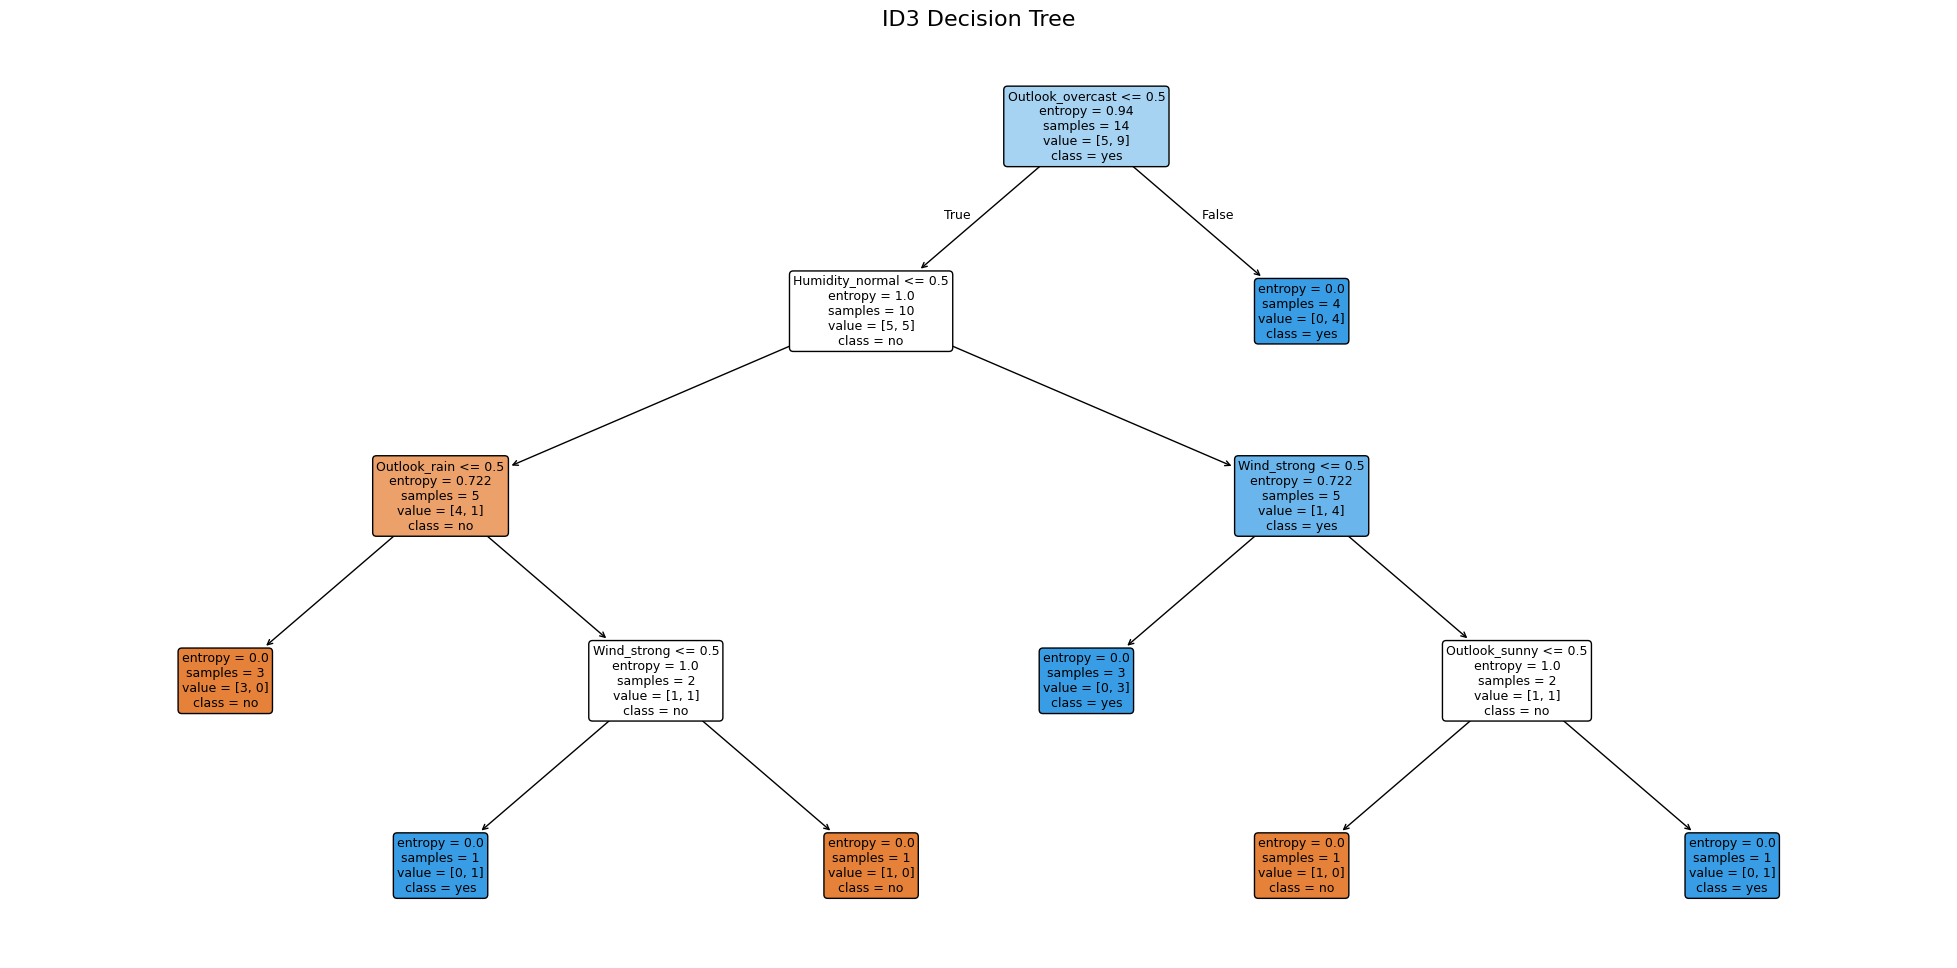


NEW SAMPLE
Outlook Temperature Humidity   Wind
  sunny        cool     high strong

PREDICTED CLASS
no


In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("ID3 Decision Tree", fontsize=16)
plt.show()


new_sample = pd.DataFrame({
    'Outlook': ['sunny'],
    'Temperature': ['cool'],
    'Humidity': ['high'],
    'Wind': ['strong']
})

sample_encoded = pd.get_dummies(new_sample)

sample_encoded = sample_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

prediction = model.predict(sample_encoded)[0]

print("\nNEW SAMPLE")
print(new_sample.to_string(index=False))

print("\nPREDICTED CLASS")
print(prediction)